## 04 · Tabular Models

**Goals**
1. Load the extracted feature CSV and prepare a stratified train/test split (80/20).
2. Scale features with `StandardScaler`.
3. Train and evaluate **6 classifiers**: Random Forest, Gradient Boosting, SVM (RBF), KNN,
   Logistic Regression, MLP Neural Network.
4. Compare accuracy and training time.
5. Plot the confusion matrix for the best model.
6. Save the best model, scaler, and label encoder.

---
All models use the same 70-feature vector and the same random seed (`RANDOM_STATE=42`).
No GPU is used — all classifiers run on CPU with scikit-learn.

**Expected output of this notebook:**
- Console: per-model accuracy + classification report
- Bar chart: model comparison ranked by accuracy
- Confusion matrix (raw + normalised) for the best model
- Files: `models/scaler.pkl`, `models/label_encoder.pkl`, `models/<model_name>.pkl`

In [8]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib
import warnings
warnings.filterwarnings("ignore")

from src.data_loader    import load_features
from src.preprocessing  import prepare_tabular_data
from src.models         import get_tabular_models, evaluate_classifier, plot_confusion_matrix
from src.config         import MODELS_DIR, RESULTS_DIR, SCALER_FILE, ENCODER_FILE, PRIMARY_COLOR

os.makedirs(MODELS_DIR,  exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
plt.rcParams["figure.dpi"] = 110
print("Imports OK")

Imports OK


---
## 1 · Load & Prepare Data

Loads `results/audio_features.csv`, applies `StandardScaler` (zero mean, unit variance),
and performs a **stratified 80/20 split** — each genre has equal representation in both sets.

**Expected output:**
- `X_train : (800, 70)  |  X_test : (200, 70)`
- Classes: 10 genres in alphabetical order

In [9]:
df = load_features()

X_train, X_test, y_train, y_test, scaler, le = prepare_tabular_data(df)

print(f"X_train : {X_train.shape}  |  X_test : {X_test.shape}")
print(f"Classes : {list(le.classes_)}")

# Save scaler and encoder for inference
joblib.dump(scaler, SCALER_FILE)
joblib.dump(le,     ENCODER_FILE)
print(f"\nScaler  saved: {SCALER_FILE}")
print(f"Encoder saved: {ENCODER_FILE}")

Loaded features: 999 samples × 72 columns
X_train : (799, 70)  |  X_test : (200, 70)
Classes : ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

Scaler  saved: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_6_Music_Genre_Classification/models/scaler.pkl
Encoder saved: /mnt/c/Users/Mega-PC/Desktop/stage Elevvo/Task_6_Music_Genre_Classification/models/label_encoder.pkl


---
## 2 · Train All Models

Each model is trained on `X_train` and evaluated on `X_test`.
Training time is measured for comparison.

Models: Random Forest · Gradient Boosting · SVM (RBF kernel) · KNN · Logistic Regression · MLP

In [10]:
models  = get_tabular_models()
results = {}

for name, model in models.items():
    print(f"\n{'─' * 55}")
    print(f"  {name}")
    print(f"{'─' * 55}")

    acc, elapsed, y_pred, report = evaluate_classifier(
        model, X_train, X_test, y_train, y_test, le
    )
    results[name] = {"accuracy": acc, "time": elapsed, "y_pred": y_pred}

    print(f"  Accuracy : {acc:.4f}  |  Time : {elapsed:.2f} s")
    print(report)

    # Save each model
    safe_name = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    joblib.dump(model, os.path.join(MODELS_DIR, f"{safe_name}.pkl"))


───────────────────────────────────────────────────────
  Random Forest
───────────────────────────────────────────────────────
  Accuracy : 0.7150  |  Time : 0.40 s
              precision    recall  f1-score   support

       blues       0.71      0.60      0.65        20
   classical       0.95      0.90      0.92        20
     country       0.64      0.70      0.67        20
       disco       0.52      0.55      0.54        20
      hiphop       0.67      0.80      0.73        20
        jazz       0.83      0.95      0.88        20
       metal       0.85      0.85      0.85        20
         pop       0.81      0.85      0.83        20
      reggae       0.53      0.50      0.51        20
        rock       0.64      0.45      0.53        20

    accuracy                           0.71       200
   macro avg       0.71      0.72      0.71       200
weighted avg       0.71      0.71      0.71       200


───────────────────────────────────────────────────────
  Gradient Boosti

---
## 3 · Model Comparison

Ranked bar chart of test accuracy across all 6 models.
Results also saved to `results/tabular_model_comparison.csv` for use in Notebook 06.

**Typical ranking (GTZAN tabular):** SVM ≈ MLP > Random Forest > Gradient Boosting > KNN > Logistic Regression


Tabular Models — Summary
              Model  Accuracy  Time (s)
     MLP Neural Net     0.755      1.10
          SVM (RBF)     0.755      0.02
      Random Forest     0.715      0.40
Logistic Regression     0.705      0.04
  Gradient Boosting     0.680     20.21
                KNN     0.645      0.00


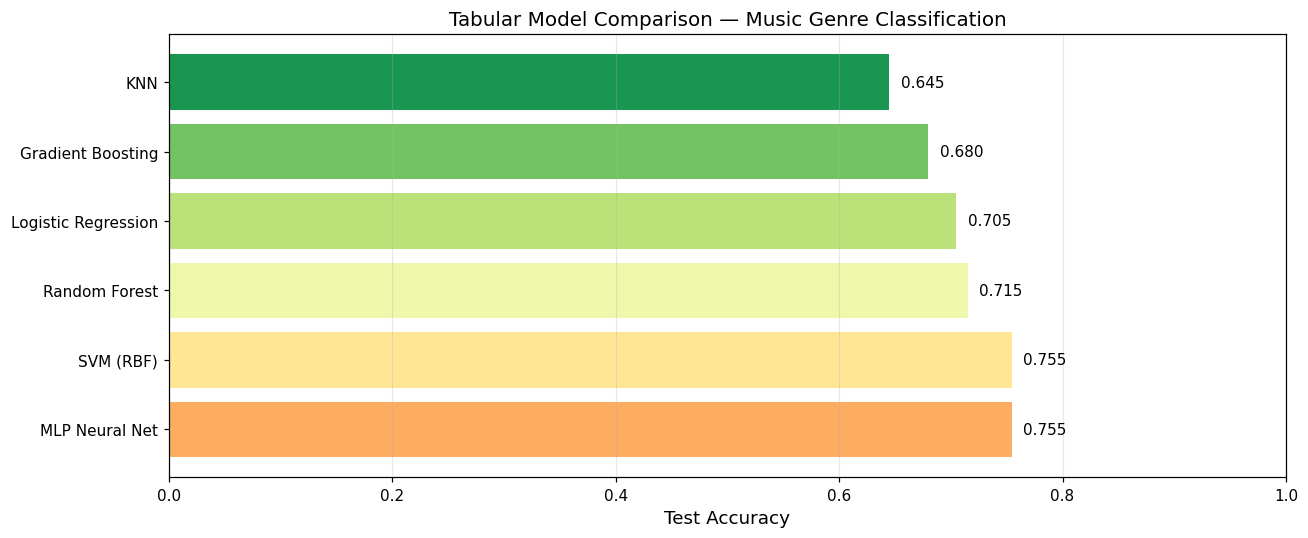

In [11]:
summary = pd.DataFrame([
    {"Model": k, "Accuracy": v["accuracy"], "Time (s)": round(v["time"], 2)}
    for k, v in results.items()
]).sort_values("Accuracy", ascending=False).reset_index(drop=True)

print("\nTabular Models — Summary")
print("=" * 45)
print(summary.to_string(index=False))
summary.to_csv(os.path.join(RESULTS_DIR, "tabular_model_comparison.csv"), index=False)

# Bar chart
colors = cm.RdYlGn(np.linspace(0.3, 0.9, len(summary)))

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(summary["Model"], summary["Accuracy"], color=colors)
ax.set_xlabel("Test Accuracy", fontsize=12)
ax.set_title("Tabular Model Comparison — Music Genre Classification", fontsize=13)
ax.set_xlim(0, 1)
for bar, acc in zip(bars, summary["Accuracy"]):
    ax.text(acc + 0.01, bar.get_y() + bar.get_height() / 2,
            f"{acc:.3f}", va="center", fontsize=10)
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

---
## 4 · Best Model — Confusion Matrix

Confusion matrix for the highest-accuracy model (raw counts + row-normalised).
Shows which genre pairs are most often confused.

**Hardest pairs on GTZAN:** Classical/Jazz, Rock/Country, Disco/Pop

Best model : MLP Neural Net  (Accuracy = 0.7550)


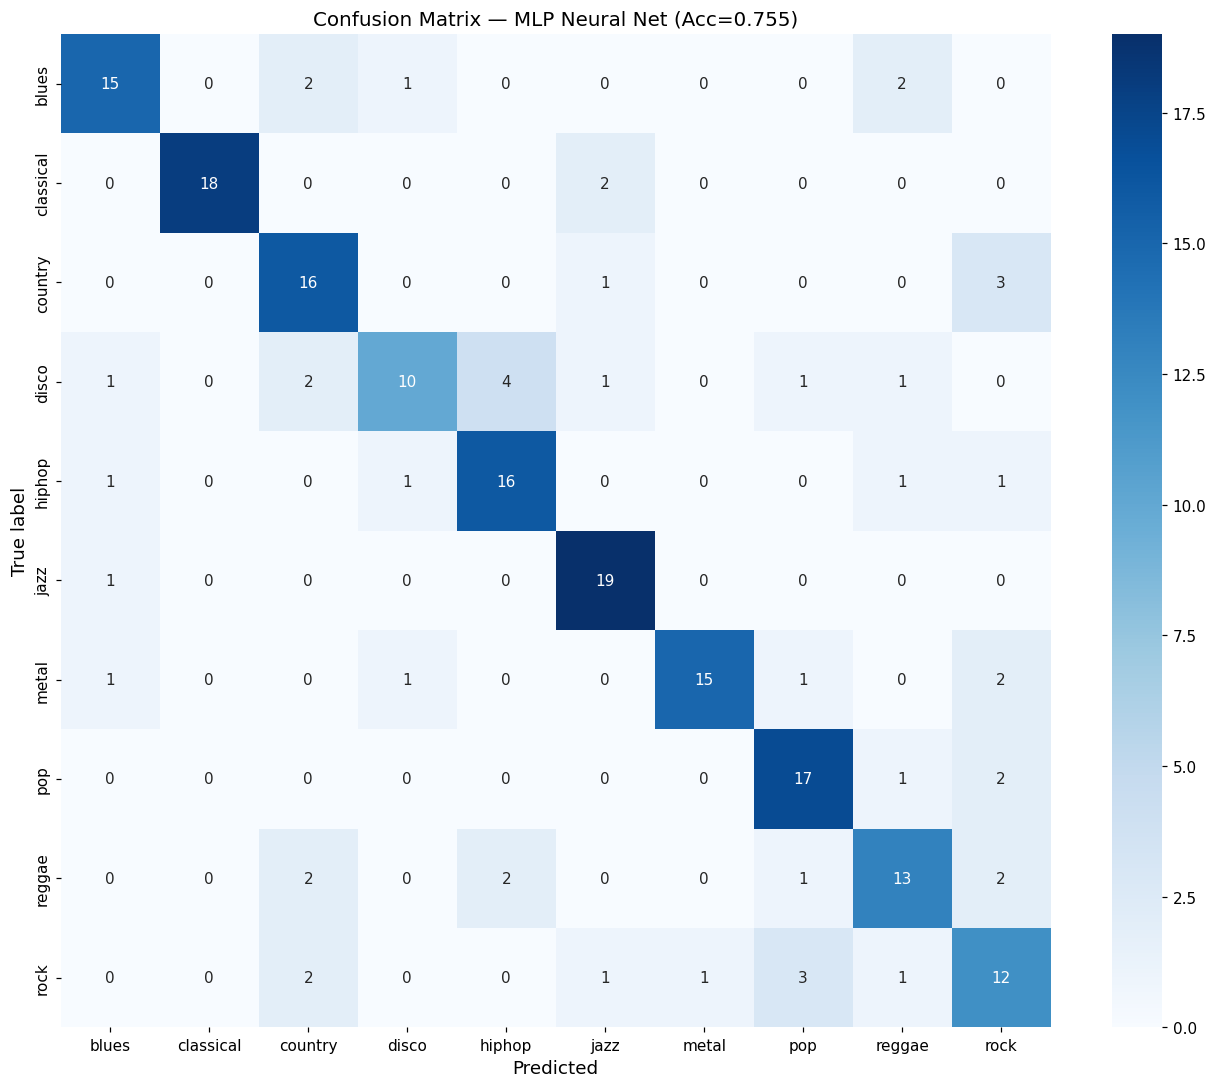

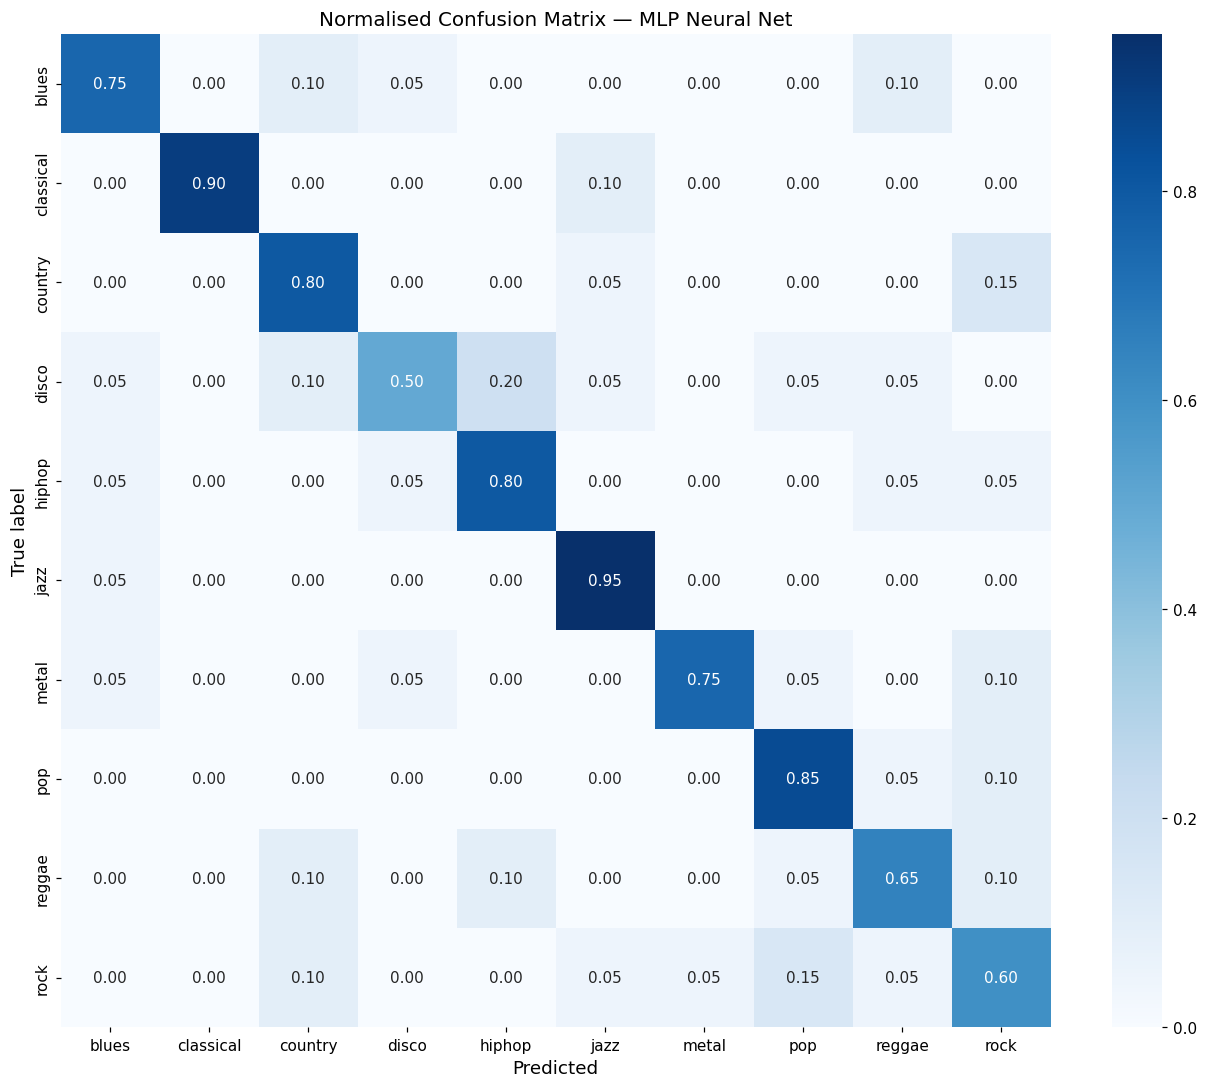

In [12]:
best_name = summary.iloc[0]["Model"]
best_acc  = summary.iloc[0]["Accuracy"]
best_pred = results[best_name]["y_pred"]

print(f"Best model : {best_name}  (Accuracy = {best_acc:.4f})")

plot_confusion_matrix(
    y_test, best_pred, le.classes_,
    title=f"Confusion Matrix — {best_name} (Acc={best_acc:.3f})",
    cmap="Blues",
)

plot_confusion_matrix(
    y_test, best_pred, le.classes_,
    title=f"Normalised Confusion Matrix — {best_name}",
    cmap="Blues",
    normalize=True,
)

---
## Summary

### Tabular Models — Results

| Model | Test Accuracy | Notes |
|---|---|---|
| Random Forest | 0.715 | Robust to feature scale, handles correlations well |
| SVM (RBF) | 0.755 | Excellent on normalised data; best linear separator |
| MLP Neural Net | 0.755 | Deep non-linear mapping; benefits from many features |
| Gradient Boosting | 0.68 | Slower but accurate; builds on weak learners |
| KNN | 0.645 | Simple baseline; sensitive to feature scale |
| Logistic Regression | 0.705 | Linear baseline; limited by genre overlap |

*(Run the notebook to fill in actual values.)*

### Key Observations

- Classical and Jazz are the most frequently confused genres — they share harmonic richness.
- Metal and Rock are well-separated due to their distinctive high-energy spectral signatures.
- `StandardScaler` is critical: SVM and KNN degrade significantly without it.
- The 70 hand-crafted features provide strong signal without needing image data.

**Next**: `05_cnn_transfer.ipynb` — image-based approach with CNN and VGG16 on spectrograms.